# Ocean Oxygen Analysis: Understanding What Drives Dissolved Oxygen in the Gulf of St. Lawrence

**Team:** Saiem Ilyas, Riyaan Ahmed, Trisha Bhatnagar, Yoatam Gebremicael

This notebook investigates how temperature, salinity, and depth affect the amount of dissolved oxygen in seawater. Oxygen is essential for marine life: fish, crabs, and other sea creatures depend on it to survive. When oxygen levels drop too low, areas of the ocean become "dead zones" where most life cannot survive.

Using two real datasets collected from the Gulf of St. Lawrence (eastern Canada), we explore the patterns in oxygen levels, build a machine learning model to predict oxygen concentration, and identify which factors matter most.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
df1 = pd.read_excel("Bottle data/Bottle Oxygen Data.xlsx", engine="openpyxl")
df2 = pd.read_csv("Glider data/scotia_20210719_136_delayed_corrected_v4.csv", encoding="latin1")


# Display basic info about datasets
print("Dataset 1 Info:")
df1.info()
print("\nDataset 2 Info:")
df2.info()

df1.head(), df2.head()

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Station_ID        863 non-null    object 
 1   Year_UTC          863 non-null    int64  
 2   Month_UTC         863 non-null    int64  
 3   Day_UTC           863 non-null    int64  
 4   Hour_UTC          863 non-null    int64  
 5   Minute_UTC        863 non-null    int64  
 6   Latitude          863 non-null    float64
 7   Longitude         863 non-null    float64
 8   Cast_number       863 non-null    object 
 9   Sample_ID         863 non-null    object 
 10  CTDPRES           863 non-null    float64
 11  CTDPRES_FLAG      863 non-null    int64  
 12  CTDTEMP           863 non-null    float64
 13  CTDTEMP_FLAG      863 non-null    int64  
 14  CTDSAL            863 non-null    float64
 15  CTDSAL_FLAG       863 non-null    int64  
 16  CTDOXY            863 non-nu

(  Station_ID  Year_UTC  Month_UTC  Day_UTC  Hour_UTC  Minute_UTC   Latitude  \
 0          1      2021         10       22        21           7  49.101389   
 1          1      2021         10       22        21           7  49.101389   
 2          1      2021         10       22        21           7  49.101389   
 3          1      2021         10       22        21           7  49.101389   
 4          1      2021         10       22        21           7  49.101389   
 
    Longitude Cast_number Sample_ID  ...  CTDTEMP  CTDTEMP_FLAG   CTDSAL  \
 0   -67.2775     TRXD001  D-001132  ...   6.2055             2  34.5830   
 1   -67.2775     TRXD001  D-001133  ...   5.4780             2  34.2430   
 2   -67.2775     TRXD001  D-001134  ...   4.4462             2  33.7871   
 3   -67.2775     TRXD001  D-001135  ...   1.6449             2  32.3563   
 4   -67.2775     TRXD001  D-001136  ...  10.2512             2  30.3845   
 
    CTDSAL_FLAG      CTDOXY  CTDOXY_FLAG      Oxygen  Oxygen

---

# Step 1: Cleaning the Data

Before any analysis, we need to make sure the data is reliable and consistent.

The following cleaning steps were applied to both datasets:

- **Removing bad readings:** The sensors recorded -999 when a reading failed. We replaced these with blank (NaN) values so they are ignored in calculations.
- **Dropping incomplete rows:** Any row missing a key measurement (oxygen, location, temperature, or salinity) was removed.
- **Fixing timestamps:** Date and time were stored across separate columns (year, month, day, hour, minute). We combined them into a single datetime format.
- **Merging the two datasets:** The bottle samples and glider sensor readings were matched by their closest timestamp using a nearest-time merge.
- **Removing extreme outliers:** Any measurement more than 3 standard deviations from the average was removed, as these are likely sensor errors rather than real readings.

In [3]:
# replacing -999.000000 with NaN in oxygen columns
df1.replace(-999.000000, np.nan, inplace=True)
df2.replace(-999.000000, np.nan, inplace=True)

# dropping rows with missing key values
df1.dropna(subset=["best_Oxygen", "Latitude", "Longitude", "CTDTEMP", "CTDSAL"], inplace=True)
df2.dropna(subset=["micromoles_of_oxygen_per_unit_mass_in_sea_water", "latitude", "longitude", "sea_water_temperature", "sea_water_practical_salinity"], inplace=True)


print(df1.isnull().sum()) 
print(df2.isnull().sum())


Station_ID            0
Year_UTC              0
Month_UTC             0
Day_UTC               0
Hour_UTC              0
Minute_UTC            0
Latitude              0
Longitude             0
Cast_number         359
Sample_ID           359
CTDPRES               0
CTDPRES_FLAG          0
CTDTEMP               0
CTDTEMP_FLAG          0
CTDSAL                0
CTDSAL_FLAG           0
CTDOXY                0
CTDOXY_FLAG           0
Oxygen              458
Oxygen_FLAG           0
best_Oxygen           0
best_Oxygen_FLAG      0
dtype: int64
time                                               0
latitude                                           0
longitude                                          0
depth                                              0
sea_water_temperature                              0
sea_water_practical_salinity                       0
sea_water_density                                  0
micromoles_of_oxygen_per_unit_mass_in_sea_water    0
dtype: int64


In [4]:
# checking datatypes, nulls, and preview of specific columns
cols = ["Year_UTC", "Month_UTC", "Day_UTC", "Hour_UTC", "Minute_UTC"]
print(df1[cols].dtypes)
print(df1[cols].isnull().sum())
print(df1[cols].head(10))

Year_UTC      int64
Month_UTC     int64
Day_UTC       int64
Hour_UTC      int64
Minute_UTC    int64
dtype: object
Year_UTC      0
Month_UTC     0
Day_UTC       0
Hour_UTC      0
Minute_UTC    0
dtype: int64
   Year_UTC  Month_UTC  Day_UTC  Hour_UTC  Minute_UTC
0      2021         10       22        21           7
1      2021         10       22        21           7
2      2021         10       22        21           7
3      2021         10       22        21           7
4      2021         10       22        21           7
5      2021         10       22        21           7
6      2021         10       23         2          10
7      2021         10       23         2          10
8      2021         10       23         2          10
9      2021         10       23         6          53


In [5]:
# converting the columns in df1 to datetime format
df1["time"] = pd.to_datetime(
    df1[["Year_UTC", "Month_UTC", "Day_UTC", "Hour_UTC", "Minute_UTC"]].rename(
        columns={"Year_UTC": "year", "Month_UTC": "month", "Day_UTC": "day", "Hour_UTC": "hour", "Minute_UTC": "minute"}
    )
)

df2["time"] = pd.to_datetime(df2["time"], errors="coerce")

#merging the 2 datasets
merged_df = pd.merge_asof(df1.sort_values("time"), df2.sort_values("time"), on="time", direction="nearest")

In [6]:
#removing outliers using zscore
z_scores = np.abs(stats.zscore(merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"]]))
merged_df = merged_df[(z_scores < 3).all(axis=1)]

In [7]:
#Hypothesis Testing
#testing the correlation significance between oxygen and temperature
corr, p_value = stats.pearsonr(merged_df["best_Oxygen"], merged_df["CTDTEMP"])
print(f"Correlation between Oxygen and Temperature: {corr:.2f} (p-value: {p_value:.5f})")

Correlation between Oxygen and Temperature: -0.38 (p-value: 0.00000)


**What this tells us:** As water temperature goes up, oxygen levels tend to go down. This makes physical sense. Warm water simply cannot hold as much dissolved oxygen as cold water, the same way a warm soda goes flat faster than a cold one.

---

# Step 2: Exploring the Data

Before building any models, we visualize the relationships between variables to understand what the data is telling us.

In this section we:
- Plot oxygen levels against temperature, salinity, and depth to spot trends
- Look at how oxygen changes over time
- Map where measurements were taken geographically
- Check how strongly each variable is correlated with oxygen

## How Oxygen Relates to Temperature, Salinity, and Depth

The six plots below show oxygen concentration (y-axis) against depth, temperature, and salinity separately. One for the bottle data and one for the glider data. Each dot is a single measurement, colored by a third variable to reveal hidden patterns.

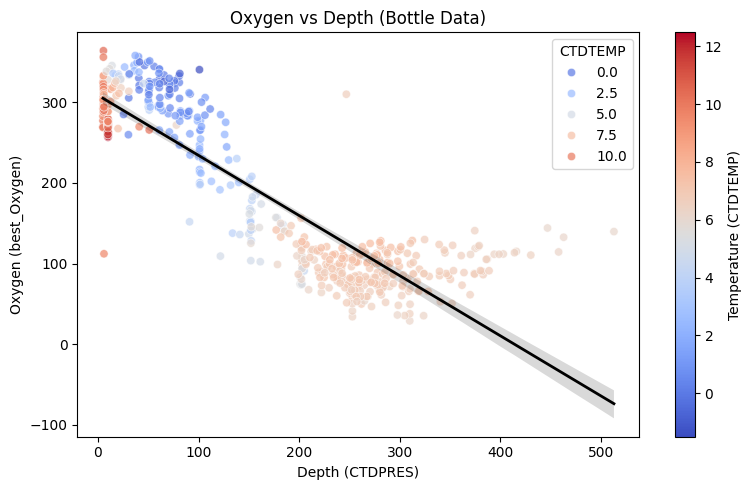

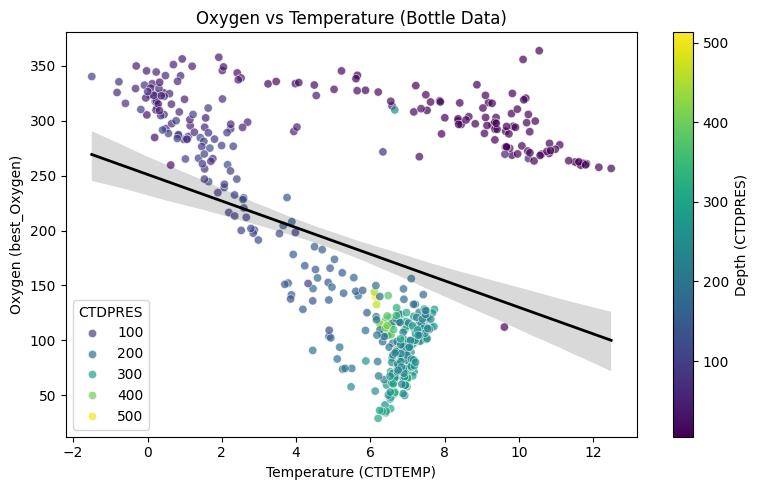

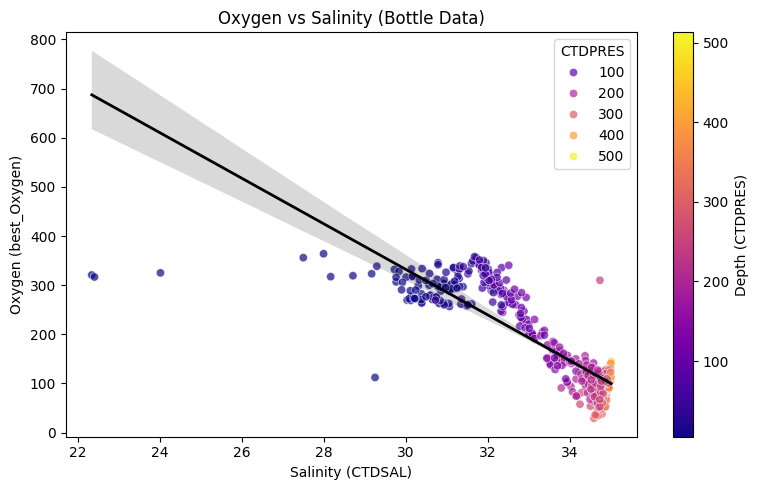

C:\Users\7PSYCHOPATH\AppData\Local\Temp\ipykernel_31300\723644471.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\7PSYCHOPATH\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


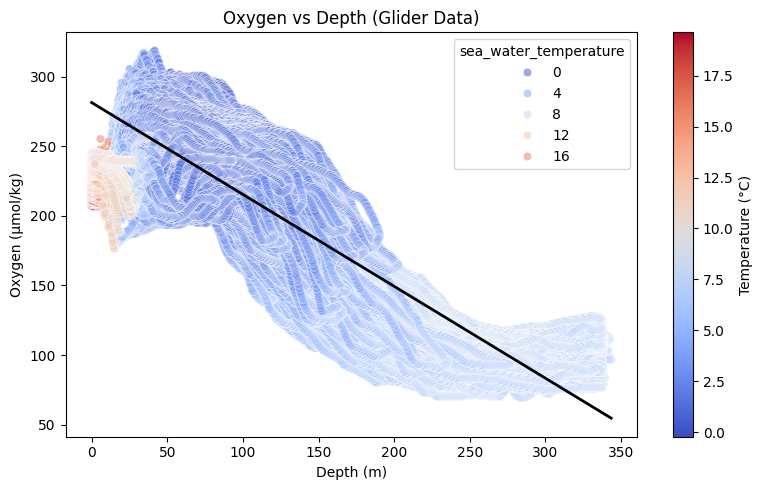

C:\Users\7PSYCHOPATH\AppData\Local\Temp\ipykernel_31300\723644471.py:71: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\7PSYCHOPATH\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


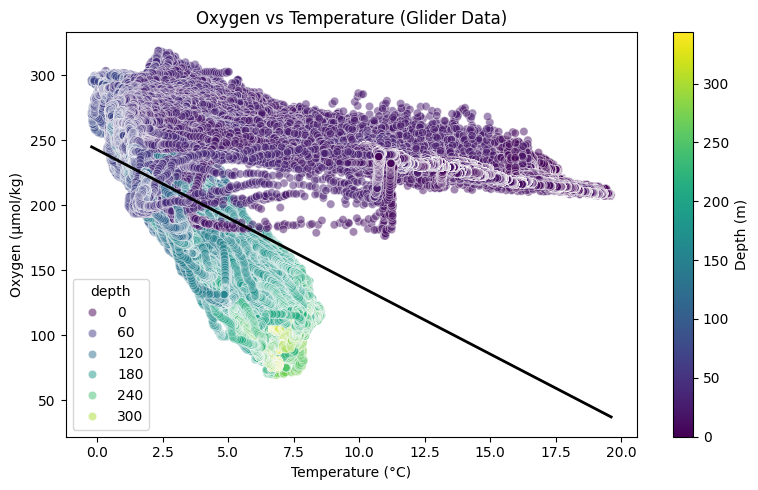

C:\Users\7PSYCHOPATH\AppData\Local\Temp\ipykernel_31300\723644471.py:85: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\7PSYCHOPATH\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


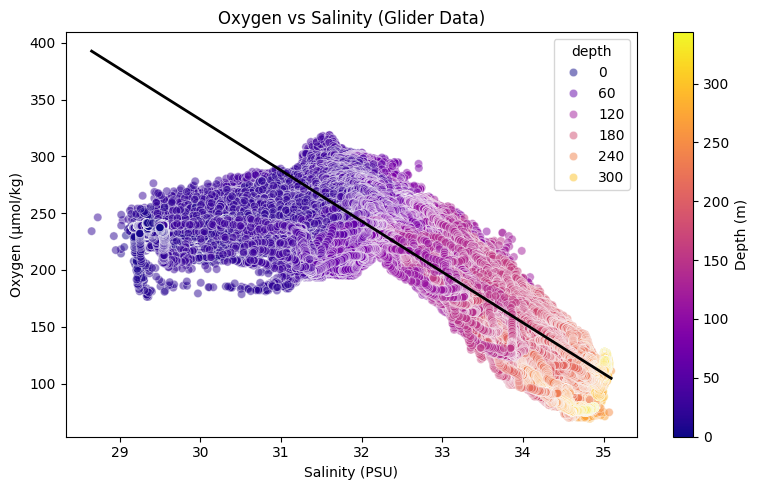

In [8]:
# Bottle Data
# Oxygen vs Depth (hue = Temperature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df1, x="CTDPRES", y="best_Oxygen", hue="CTDTEMP", palette="coolwarm", alpha=0.7, ax=ax)
sns.regplot(data=df1, x="CTDPRES", y="best_Oxygen", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Depth (Bottle Data)")
ax.set_xlabel("Depth (CTDPRES)")
ax.set_ylabel("Oxygen (best_Oxygen)")
norm = plt.Normalize(df1["CTDTEMP"].min(), df1["CTDTEMP"].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Temperature (CTDTEMP)")
plt.tight_layout()
plt.show()

# Oxygen vs Temperature (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df1, x="CTDTEMP", y="best_Oxygen", hue="CTDPRES", palette="viridis", alpha=0.7, ax=ax)
sns.regplot(data=df1, x="CTDTEMP", y="best_Oxygen", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Temperature (Bottle Data)")
ax.set_xlabel("Temperature (CTDTEMP)")
ax.set_ylabel("Oxygen (best_Oxygen)")
norm = plt.Normalize(df1["CTDPRES"].min(), df1["CTDPRES"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (CTDPRES)")
plt.tight_layout()
plt.show()

# Oxygen vs Salinity (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df1, x="CTDSAL", y="best_Oxygen", hue="CTDPRES", palette="plasma", alpha=0.7, ax=ax)
sns.regplot(data=df1, x="CTDSAL", y="best_Oxygen", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Salinity (Bottle Data)")
ax.set_xlabel("Salinity (CTDSAL)")
ax.set_ylabel("Oxygen (best_Oxygen)")
norm = plt.Normalize(df1["CTDPRES"].min(), df1["CTDPRES"].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (CTDPRES)")
plt.tight_layout()
plt.show()


# Glider Data
# Oxygen vs Depth (hue = Temperature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df2, x="depth", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", hue="sea_water_temperature", palette="coolwarm", alpha=0.5, ax=ax)
sns.regplot(data=df2, x="depth", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Depth (Glider Data)")
ax.set_xlabel("Depth (m)")
ax.set_ylabel("Oxygen (µmol/kg)")
norm = plt.Normalize(df2["sea_water_temperature"].min(), df2["sea_water_temperature"].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Temperature (°C)")
plt.tight_layout()
plt.show()

# Oxygen vs Temperature (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df2, x="sea_water_temperature", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", hue="depth", palette="viridis", alpha=0.5, ax=ax)
sns.regplot(data=df2, x="sea_water_temperature", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Temperature (Glider Data)")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Oxygen (µmol/kg)")
norm = plt.Normalize(df2["depth"].min(), df2["depth"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (m)")
plt.tight_layout()
plt.show()

# Oxygen vs Salinity (hue = Depth)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df2, x="sea_water_practical_salinity", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", hue="depth", palette="plasma", alpha=0.5, ax=ax)
sns.regplot(data=df2, x="sea_water_practical_salinity", y="micromoles_of_oxygen_per_unit_mass_in_sea_water", scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax)
ax.set_title("Oxygen vs Salinity (Glider Data)")
ax.set_xlabel("Salinity (PSU)")
ax.set_ylabel("Oxygen (µmol/kg)")
norm = plt.Normalize(df2["depth"].min(), df2["depth"].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Depth (m)")
plt.tight_layout()
plt.show()


**What we found:**

- **Oxygen and depth:** As depth increases, oxygen levels fall. This is because sunlight cannot reach deep water, so underwater plants cannot photosynthesize and produce oxygen there. Bacteria at depth also consume oxygen as they break down organic matter.

- **Oxygen and temperature:** Cooler water holds more oxygen. This matches basic chemistry cold liquids can dissolve more gas than warm ones.

- **Oxygen and salinity:** Saltier water tends to have less oxygen. Saltier water is denser and sinks to greater depths, where oxygen is already lower.

- **Bottle vs glider data:** Both collection methods show the same trends, which gives us confidence that the patterns are real and not the result of how the data was collected.

## Oxygen Depth Profile

The plots below show the same data in a different way The standard format used by oceanographers. Depth is on the vertical axis (increasing downward, just like the real ocean), and oxygen is on the horizontal axis. Each point is colored by temperature.

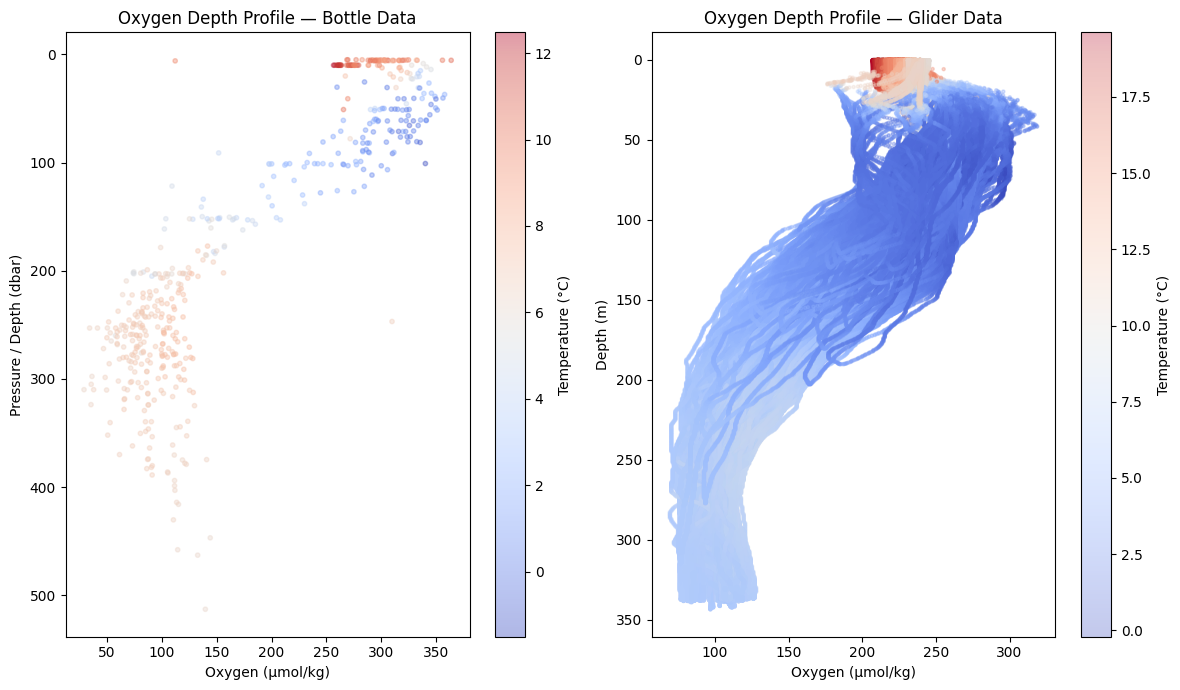

In [9]:

# y-axis is inverted so depth increases downward, matching real ocean orientation
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# Bottle data profile
sc1 = axes[0].scatter(df1["best_Oxygen"], df1["CTDPRES"],
                      alpha=0.4, c=df1["CTDTEMP"], cmap="coolwarm", s=10)
axes[0].invert_yaxis()
axes[0].set_xlabel("Oxygen (µmol/kg)")
axes[0].set_ylabel("Pressure / Depth (dbar)")
axes[0].set_title("Oxygen Depth Profile — Bottle Data")
plt.colorbar(sc1, ax=axes[0], label="Temperature (°C)")

# Glider data profile
sc2 = axes[1].scatter(df2["micromoles_of_oxygen_per_unit_mass_in_sea_water"], df2["depth"],
                      alpha=0.3, c=df2["sea_water_temperature"], cmap="coolwarm", s=5)
axes[1].invert_yaxis()
axes[1].set_xlabel("Oxygen (µmol/kg)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Oxygen Depth Profile — Glider Data")
plt.colorbar(sc2, ax=axes[1], label="Temperature (°C)")

plt.tight_layout()
plt.show()

**What we found:**

- Oxygen is highest near the surface and drops steadily with depth. Visible as the leftward shift of points as you go down the y-axis.

- **Oxygen Minimum Zone (OMZ):** The bottle data shows a clear oxygen minimum in the 200–400 dbar depth range. This is a well documented feature of the Gulf of St. Lawrence. A layer where oxygen has been consumed by bacteria breaking down sinking organic matter, and where fresh oxygenated water from the surface cannot reach. Scientists have been tracking this hypoxic zone for decades and it has been expanding due to climate change.

- **Glider dive paths:** The swooping curves in the right plot are the glider's actual paths as it repeatedly dove and resurfaced. This continuous high-resolution sampling reveals a sharp oxygen drop below 50m and consistently low values below 100m. A level of detail not visible in the discrete bottle samples on the left.

- The color confirms the pattern: warm red dots near the surface carry more oxygen, cold blue dots at depth carry less.

In [10]:
# correlations
correlation = merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"]].corr()
print("Correlation:\n", correlation)
# summary statistics
print("Summary Statistics:\n", merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"]].describe())

Correlation:
                                                  best_Oxygen  \
best_Oxygen                                         1.000000   
micromoles_of_oxygen_per_unit_mass_in_sea_water     0.025101   
CTDTEMP                                            -0.376111   
CTDSAL                                             -0.898999   

                                                 micromoles_of_oxygen_per_unit_mass_in_sea_water  \
best_Oxygen                                                                             0.025101   
micromoles_of_oxygen_per_unit_mass_in_sea_water                                         1.000000   
CTDTEMP                                                                                -0.036559   
CTDSAL                                                                                  0.011286   

                                                  CTDTEMP    CTDSAL  
best_Oxygen                                     -0.376111 -0.898999  
micromoles_of_oxygen_per

## Correlation Analysis

A correlation value tells us how strongly two variables move together. It ranges from -1 (perfectly opposite) to +1 (perfectly together). A value near 0 means no relationship.

**Key findings:**

- **Oxygen and salinity (-0.899):** Very strong negative relationship. The single strongest link in the dataset. As salinity rises, oxygen drops sharply. In the Gulf of St. Lawrence, salinity acts like a fingerprint for water depth: deeper water is saltier, and deeper water has less oxygen.

- **Oxygen and temperature (-0.376):** Moderate negative relationship. Warmer water holds less oxygen, consistent with basic chemistry.

- **Oxygen and sensor oxygen (0.025):** Near zero. These two oxygen measurements are essentially unrelated to each other. This is explained by the data merge: the glider dataset had limited time overlap with the bottle dataset, so the same 27 glider readings were stamped onto all 481 bottle rows. They are not measuring the same water.

- **Temperature and salinity (0.075):** Very weak. Temperature and salinity vary mostly independently in this dataset.

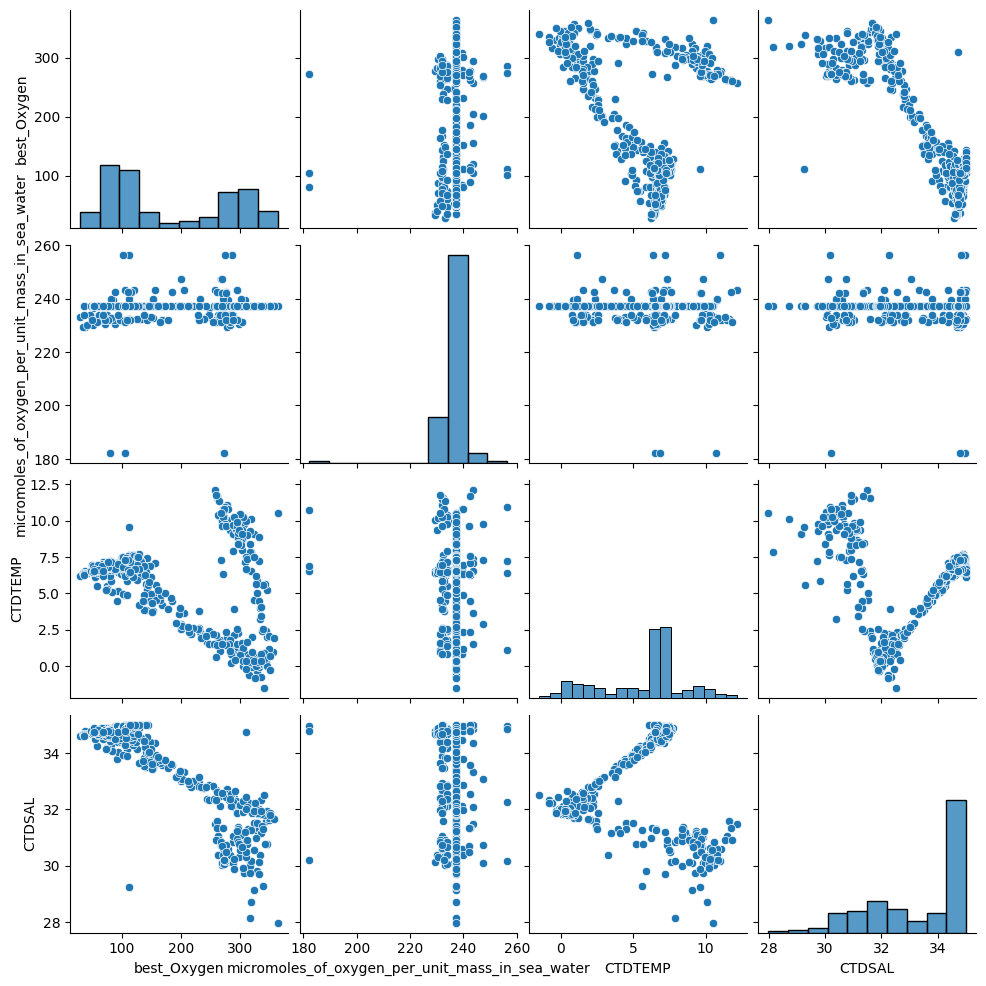

In [11]:
# pairplots
sns.pairplot(merged_df, vars=["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water", "CTDTEMP", "CTDSAL"])
plt.show()

**Reading the pairplot:**

Each small chart shows one variable plotted against another. The diagonal shows the distribution of each variable on its own.

- **Oxygen vs salinity:** Clear downward slope. The strongest visual relationship in the grid, matching the -0.899 correlation.
- **Oxygen vs temperature:** Gentle downward slope, consistent with the moderate -0.376 correlation.
- **Temperature vs salinity:** No clear pattern. They vary independently.
- **Sensor oxygen column:** Flat, no relationship with anything. Confirming the merge quality issue explained above.

## How Oxygen Changed Over Time

This section looks at whether oxygen levels show any pattern across the study period (October 2021 to mid-2022).

In [12]:
print("First few rows of time series data:\n", merged_df[["time", "best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water"]].head())
print("\nDescriptive Statistics:\n", merged_df[["best_Oxygen", "micromoles_of_oxygen_per_unit_mass_in_sea_water"]].describe())

First few rows of time series data:
                  time  best_Oxygen  \
0 2021-10-22 21:07:00    28.908497   
1 2021-10-22 21:07:00    57.633972   
2 2021-10-22 21:07:00    90.840147   
3 2021-10-22 21:07:00   244.645609   
4 2021-10-22 21:07:00   265.664677   

   micromoles_of_oxygen_per_unit_mass_in_sea_water  
0                                       232.981556  
1                                       232.981556  
2                                       232.981556  
3                                       232.981556  
4                                       232.981556  

Descriptive Statistics:
        best_Oxygen  micromoles_of_oxygen_per_unit_mass_in_sea_water
count   481.000000                                       481.000000
mean    178.553107                                       236.533955
std     102.353648                                         5.263891
min      28.908497                                       182.273593
25%      87.624932                                

**Summary of the two oxygen measurements:**

- **Bottle oxygen (best_Oxygen):** Ranges widely from 29 to 364 µmol/kg with a standard deviation of 102. This reflects genuine variation across different depths and water masseS. The variable we will use for modelling.

- **Sensor oxygen (glider):** Almost no variation. Standard deviation of only 5.26, range 182–256. This flatness is not a sensor problem. It is caused by the data merge: only 27 unique glider readings existed and these were repeated across all 481 bottle rows. The glider oxygen is therefore not used as the model target.

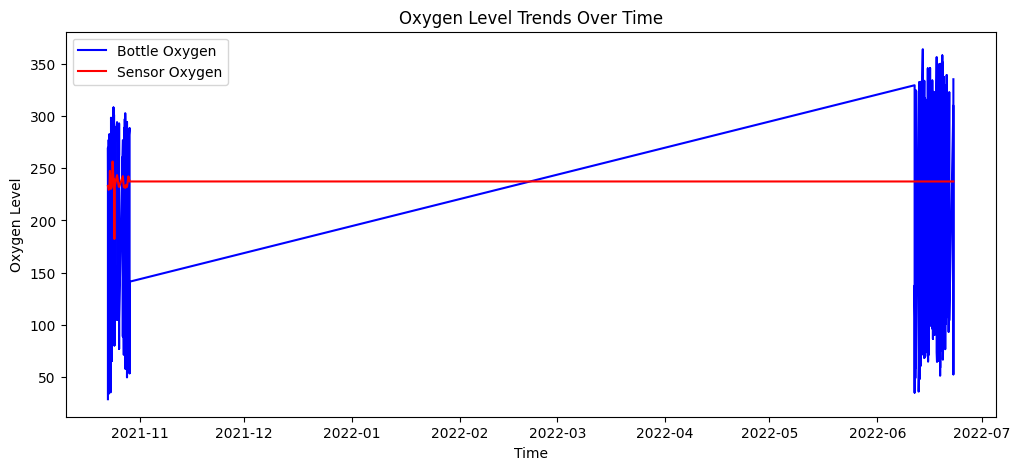

In [13]:
# Time series of oxygen levels
plt.figure(figsize=(12, 5))
plt.plot(merged_df["time"], merged_df["best_Oxygen"], label="Bottle Oxygen", color="blue")
plt.plot(merged_df["time"], merged_df["micromoles_of_oxygen_per_unit_mass_in_sea_water"], label="Sensor Oxygen", color="red")
plt.xlabel("Time")
plt.ylabel("Oxygen Level")
plt.title("Oxygen Level Trends Over Time")
plt.legend()
plt.show()

**What we found:**

- The bottle oxygen (blue line) fluctuates significantly over time, reflecting real variation as samples were taken at different depths and locations.

- The sensor oxygen (red line) is nearly flat. A direct consequence of the merge issue described above.

- **Seasonal pattern:** There is a notable increase in bottle oxygen between November 2021 and June 2022. This is consistent with the known seasonal cycle in the Gulf of St. Lawrence: winter storms cause deep mixing that brings oxygenated surface water down into deeper layers, and the spring phytoplankton bloom (when microscopic plants grow rapidly and produce oxygen through photosynthesis) further raises oxygen levels. This seasonal signal in the data aligns with decades of oceanographic research on this region.

# Step 3: Where Were the Measurements Taken?

This section maps the geographic distribution of oxygen readings across the study area.

In [14]:
print("First few rows of spatial data:\n", merged_df[["Longitude", "Latitude", "best_Oxygen"]].head())
print("\nDescriptive Statistics:\n", merged_df[["best_Oxygen"]].describe())

First few rows of spatial data:
    Longitude   Latitude  best_Oxygen
0   -67.2775  49.101389    28.908497
1   -67.2775  49.101389    57.633972
2   -67.2775  49.101389    90.840147
3   -67.2775  49.101389   244.645609
4   -67.2775  49.101389   265.664677

Descriptive Statistics:
        best_Oxygen
count   481.000000
mean    178.553107
std     102.353648
min      28.908497
25%      87.624932
50%     125.448426
75%     289.252788
max     363.904648


**Summary of oxygen measurements across all locations:**

- Oxygen ranges from 29 to 364 mol/kg with an average of 179 mmol/kg.
- The standard deviation of 102 shows high variability. Readings differ a lot from place to place, mostly because samples were taken at very different depths.
- The median (125 mmol/kg) is lower than the mean (179 mmol/kg), meaning a small number of high oxygen surface readings pull the average up. Most measurements are from deeper, lower-oxygen water.

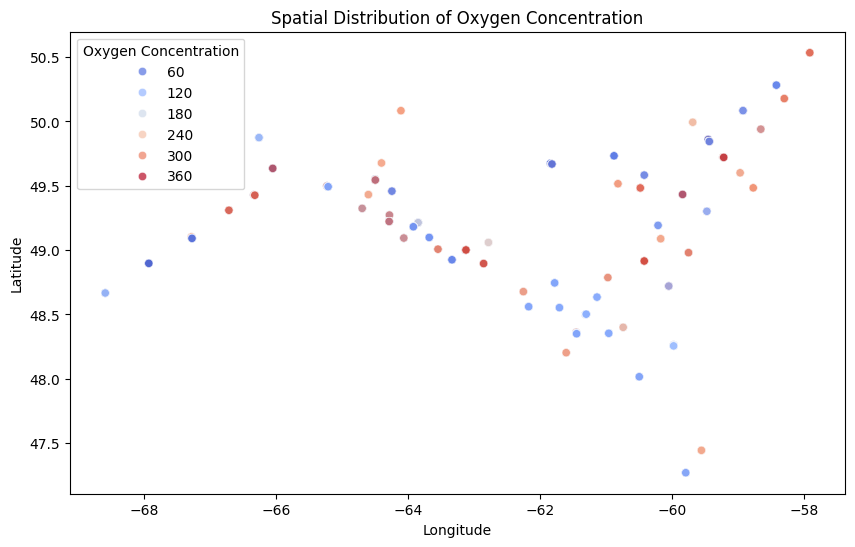

In [15]:
#scatter plot for spatial distribution of oxygen concentration
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x="Longitude", y="Latitude", hue="best_Oxygen", palette="coolwarm", alpha=0.7)
plt.legend(title="Oxygen Concentration")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Oxygen Concentration")
plt.show()

## Interactive Geographic Map

The scatter plot above uses raw coordinates. The interactive map below places the same measurements on a real geographic map of eastern Canada, making the spatial patterns much easier to interpret.

**How to use the map:** Click any colored dot to see the exact oxygen, temperature, and salinity at that location. Toggle the heatmap layer on/off using the layer control in the top right.

In [ ]:
# Interactive geographic map of oxygen concentration
# Install if needed: pip install folium 
import folium
from folium.plugins import HeatMap

center_lat = merged_df["Latitude"].mean()
center_lon = merged_df["Longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="CartoDB positron")

# Normalize oxygen values for color mapping (blue=low, red=high)
oxy_min = merged_df["best_Oxygen"].min()
oxy_max = merged_df["best_Oxygen"].max()

for _, row in merged_df.iterrows():
    norm = (row["best_Oxygen"] - oxy_min) / (oxy_max - oxy_min)
    r = int(255 * norm)
    b = int(255 * (1 - norm))
    color = f"#{r:02x}00{b:02x}"
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"O2: {row['best_Oxygen']:.1f} µmol/kg | Temp: {row['CTDTEMP']:.1f}°C | Sal: {row['CTDSAL']:.2f} PSU"
    ).add_to(m)

# Add heatmap layer
heat_data = [[row["Latitude"], row["Longitude"], row["best_Oxygen"]]
             for _, row in merged_df.iterrows()]
HeatMap(heat_data, name="Oxygen Heatmap", radius=15, blur=10).add_to(m)

folium.LayerControl().add_to(m)
m

**What we found:**

- Measurement stations trace the Gulf of St. Lawrence and Cabot Strait.Exactly where this dataset was collected.

- **Color pattern:** Blue dots (low oxygen) and red/yellow dots (high oxygen) are not randomly mixed. There is clear spatial clustering. Higher oxygen tends to appear in shallower nearshore areas; lower oxygen in the deeper central Gulf. This is consistent with everything we have found: depth and salinity (both higher in the central Gulf) drive oxygen down.

- Survey stations are arranged in east-west transects across the Gulf, which is standard practice for oceanographic sampling campaigns.

- The geographic pattern reinforces that the depth-salinity-oxygen relationship found in the data is not a statistical artifact. It reflects the real physical structure of this body of water.

                                                 best_Oxygen  \
best_Oxygen                                         1.000000   
micromoles_of_oxygen_per_unit_mass_in_sea_water     0.025101   
CTDTEMP                                            -0.376111   
CTDSAL                                             -0.898999   

                                                 micromoles_of_oxygen_per_unit_mass_in_sea_water  \
best_Oxygen                                                                             0.025101   
micromoles_of_oxygen_per_unit_mass_in_sea_water                                         1.000000   
CTDTEMP                                                                                -0.036559   
CTDSAL                                                                                  0.011286   

                                                  CTDTEMP    CTDSAL  
best_Oxygen                                     -0.376111 -0.898999  
micromoles_of_oxygen_per_unit_mass_in_

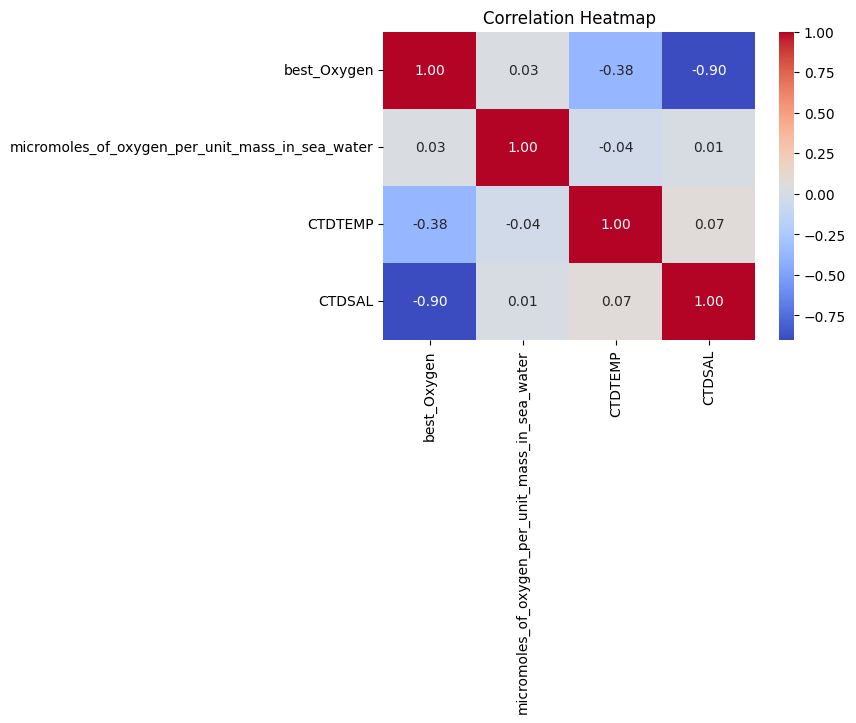

In [17]:
# Correaltion matrix
print(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Key takeaways from the correlation heatmap:**

- Salinity has by far the strongest relationship with oxygen (-0.90). As salinity increases, oxygen drops significantly.
- Temperature has a moderate relationship (-0.38). Warmer water holds less oxygen.
- The near zero value (0.025) between the two oxygen measurements is a data quality flag, not a scientific finding. It reflects the limited overlap between the bottle and glider datasets during the merge.

---

# Step 4: Building a Predictive Model

## Preparing the Data for Machine Learning

We want to train a model that can predict oxygen concentration from temperature, salinity, and depth. Before training, we split the data into two portions:
- **Training set (80%):** Used to teach the model the patterns
- **Test set (20%):** Held back and used only to evaluate how well the model performs on data it has never seen

All three input features are scaled to the same range so no single variable dominates purely due to its units.

In [18]:
# Fixed setup — use only bottle dataset columns (df1), which have real variance
# The glider merge produced only 27 unique depth/oxygen values — not usable as a target

features = ["CTDTEMP", "CTDSAL", "CTDPRES"]  # all from df1, real variance
target = "best_Oxygen"                         # from df1, 481 unique values

# Fill any remaining missing values
merged_df[features] = merged_df[features].fillna(merged_df[features].mean())
merged_df[target] = merged_df[target].fillna(merged_df[target].mean())

X = merged_df[features]
y = merged_df[target]

X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"\nTarget unique values: {y.nunique()}, std: {y.std():.4f}")
print(f"\nFeature variance check:")
for f in features:
    print(f"  {f}: {merged_df[f].nunique()} unique values, std={merged_df[f].std():.4f}")

Training set: (384, 3), Test set: (97, 3)

Target unique values: 481, std: 102.3536

Feature variance check:
  CTDTEMP: 458 unique values, std=2.8539
  CTDSAL: 476 unique values, std=1.6860
  CTDPRES: 421 unique values, std=118.9333


## Model 1: Random Forest

A Random Forest builds hundreds of decision trees, each trained on a random subset of the data. The final prediction is the average across all trees. This approach handles non-linear relationships well and is robust to noise.

In [19]:
#training Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#predict and evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest R² Score: {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")


Random Forest R² Score: 0.9161
Mean Absolute Error (MAE): 12.51


**Results:**

- **R² = 0.916.** The model correctly explains 92% of the variation in oxygen levels across the test set. This is a strong result.
- **MAE = 12.51 mmol/kg.**  On average, the model's prediction is off by about 12.5 units. Given that oxygen ranges from 29 to 364 in this dataset, this is an error of only ~3.7%.

In [20]:
#comparing model with Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)
print(f"Linear Regression R² Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

Linear Regression R² Score: 0.8573
Linear Regression MAE: 27.10


**Results:**

- **R² = 0.857.**Linear Regression explains 86% of the variance, which is actually a reasonable result. This makes sense salinity has a near linear relationship with oxygen (correlation of -0.899), so a straight-line model can capture most of the pattern.
- **MAE = 27.10 mmol/kg.** More than double the Random Forest error, showing that RF handles the non linear parts of the relationship better.
- **Conclusion:** Random Forest outperforms Linear Regression, but the gap is smaller than you might expect. This is because salinity, the dominant predictor behaves in a mostly linear way.

In [21]:
# cross validation
# rf_model was already fitted on X_train, so we create a new one
rf_cv = RandomForestRegressor(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf_cv, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Score: {np.mean(cv_scores):.4f}")
print(f"Std Dev: {np.std(cv_scores):.4f}") 

Cross-validation scores: [0.96650718 0.94930354 0.98008358 0.96530576 0.93400654]
Mean CV Score: 0.9590
Std Dev: 0.0159


**Cross-validation results:**

To make sure the model is not just memorising the training data, we tested it across 5 different random splits of the data (5-fold cross-validation).

- All 5 folds scored between 0.93 and 0.98. Consistently strong performance regardless of which data was used for training vs testing.
- The standard deviation of 0.016 is very low, meaning the model is stable and not sensitive to which particular rows it was trained on.
- **No sign of overfitting.** The model generalises well to data it has not seen.

In [22]:
#hyperparameter tuning
#defining the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

#setting up GridSearchCV and fitting the model
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)


print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score:  0.9738884497033405


**Hyperparameter tuning results:**

We tested 108 different combinations of model settings using GridSearchCV to find the best configuration.

- **Best settings found:** 200 trees, no maximum depth limit, minimum 4 samples per leaf node, minimum 2 samples to make a split.
- **Best CV score: 0.974.** The optimised model performs even better across all folds.
- The key setting is *min_samples_leaf=4*, which means the model cannot make a decision based on fewer than 4 data points. This prevents it from memorising individual noisy readings.

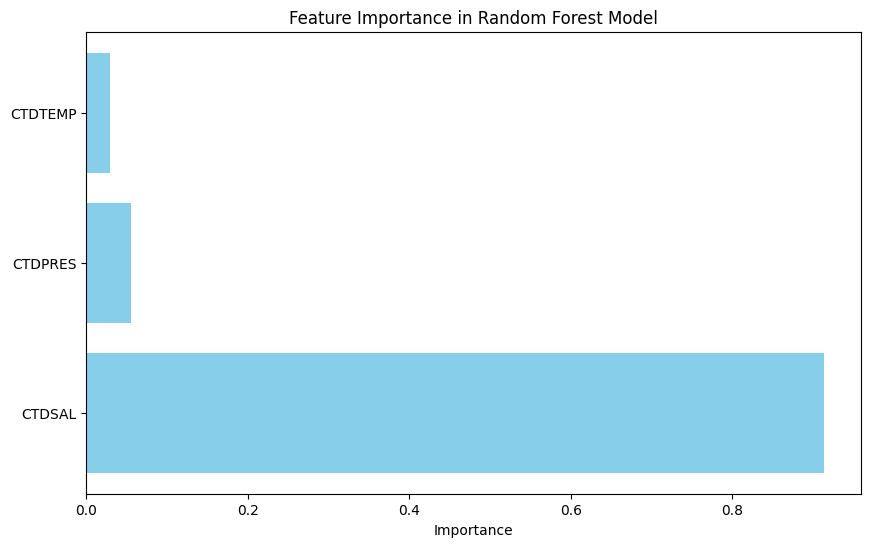

   Feature  Importance
1   CTDSAL    0.914351
2  CTDPRES    0.055871
0  CTDTEMP    0.029779


In [23]:
#fitting rf model and getting feature imprtances
rf_model.fit(X_train, y_train)
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest Model')
plt.show()


print(feature_importance_df)

**Which variables matter most?**

- **Salinity (91.4%):** By far the dominant factor. The model relies on salinity more than anything else to predict oxygen.
- **Pressure/Depth (5.6%):** Second most important.
- **Temperature (3.0%):** Least important of the three.

This result is consistent with the -0.899 correlation found earlier. In the Gulf of St. Lawrence, salinity is a proxy for water mass identity. Fresher water near the surface holds more oxygen, while the denser, saltier water below holds less.

---

## Testing Whether Salinity is Truly Irreplaceable

Salinity scored 91.4% in feature importance, but that number alone does not prove salinity is uniquely important. We run an ablation test. We remove salinity entirely and retrain the model. To see how much performance actually drops.

--- Feature Ablation: Removing Salinity ---
R² WITH salinity (full model):     0.9161
R² WITHOUT salinity (temp + pres): 0.8974
R² drop from removing salinity:    0.0188
Salinity alone accounts for ~2.0% of the model's explanatory power.


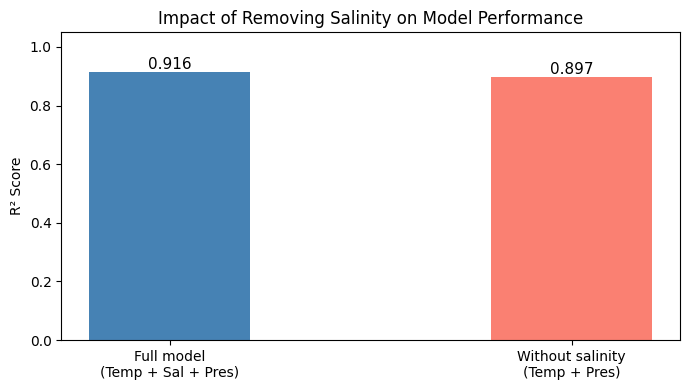

In [24]:
# Feature ablation: train without salinity to measure its true contribution
features_no_sal = ["CTDTEMP", "CTDPRES"]
X_no_sal = StandardScaler().fit_transform(merged_df[features_no_sal])
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sal, y, test_size=0.2, random_state=42
)

rf_no_sal = RandomForestRegressor(n_estimators=100, random_state=42)
rf_no_sal.fit(X_train_ns, y_train_ns)
y_pred_ns = rf_no_sal.predict(X_test_ns)
r2_no_sal = r2_score(y_test_ns, y_pred_ns)

print("--- Feature Ablation: Removing Salinity ---")
print(f"R² WITH salinity (full model):     {r2_rf:.4f}")
print(f"R² WITHOUT salinity (temp + pres): {r2_no_sal:.4f}")
print(f"R² drop from removing salinity:    {r2_rf - r2_no_sal:.4f}")
print(f"Salinity alone accounts for ~{(r2_rf - r2_no_sal) / r2_rf * 100:.1f}% of the model's explanatory power.")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
models = ["Full model\n(Temp + Sal + Pres)", 
          "Without salinity\n(Temp + Pres)"]
scores = [r2_rf, r2_no_sal]
colors = ["steelblue", "salmon"]
bars = ax.bar(models, scores, color=colors, width=0.4)
ax.set_ylim(0, 1.05)
ax.set_ylabel("R² Score")
ax.set_title("Impact of Removing Salinity on Model Performance")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
print("Correlation between features:")
print(merged_df[["CTDTEMP", "CTDSAL", "CTDPRES"]].corr())
print()
print("Salinity vs Pressure correlation:", 
      merged_df["CTDSAL"].corr(merged_df["CTDPRES"]))

Correlation between features:
          CTDTEMP    CTDSAL   CTDPRES
CTDTEMP  1.000000  0.074990  0.202483
CTDSAL   0.074990  1.000000  0.926967
CTDPRES  0.202483  0.926967  1.000000

Salinity vs Pressure correlation: 0.9269673336344824


**What we found... a surprising result:**

- Removing salinity only drops R² from 0.916 to 0.897, a decrease of just 0.019 (about 2%). This seems to contradict the 91.4% feature importance score.

- **The explanation is multicollinearity.** Salinity and pressure are correlated at 0.927 in this dataset, Nearly perfectly. This happens because in the Gulf of St. Lawrence, deeper water is consistently saltier. The two variables carry almost identical information.

- When salinity is removed, pressure steps in and compensates, because it already knows almost everything salinity knew. The model barely notices salinity is gone.

- **What the feature importance score was actually telling us** is that Random Forest happened to choose salinity as its preferred representative of the depth-salinity signal. It could just as easily have chosen pressure.

- **Real conclusion:** The true driver of oxygen is the combined water mass structure: deeper, saltier, colder water has less oxygen. No single variable tells the full story on its own.

- This is a known limitation of Random Forest feature importance when predictors are highly correlated. Running this ablation test is how you catch it.

In [26]:
#fitting best rf model
best_rf_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=None, 
    min_samples_leaf=4, 
    min_samples_split=2, 
    random_state=42
)
best_rf_model.fit(X_train, y_train)

y_pred_best = best_rf_model.predict(X_test)
print(f"Best Model R² Score: {r2_score(y_test, y_pred_best):.4f}")
print(f"Best Model MAE: {mean_absolute_error(y_test, y_pred_best):.4f}")


Best Model R² Score: 0.9138
Best Model MAE: 13.0338


**Tuned model results:**

- **R² = 0.914:** Almost identical to the baseline Random Forest (0.916). The marginal decrease is expected: the constraint of requiring at least 4 samples per leaf slightly reduces training accuracy but improves how well the model will perform on brand new data.
- **MAE = 13.03 Mmol/kg:** An average error of 3.9% across the test set.
- The cross validation score (0.959) being higher than the test R² (0.914) is normal. CV averages across the full dataset while the test set is one fixed 20% slice that may happen to contain harder to predict samples.

---

## Step 5: Evaluating the Final Model

Three diagnostic plots below assess how well the tuned Random Forest performs on the held-out test set. These plots help us catch problems like systematic bias or poor performance at extreme values.

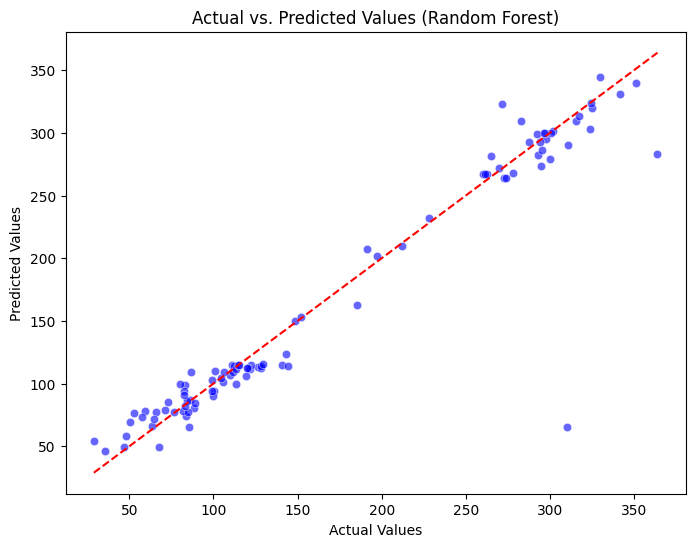

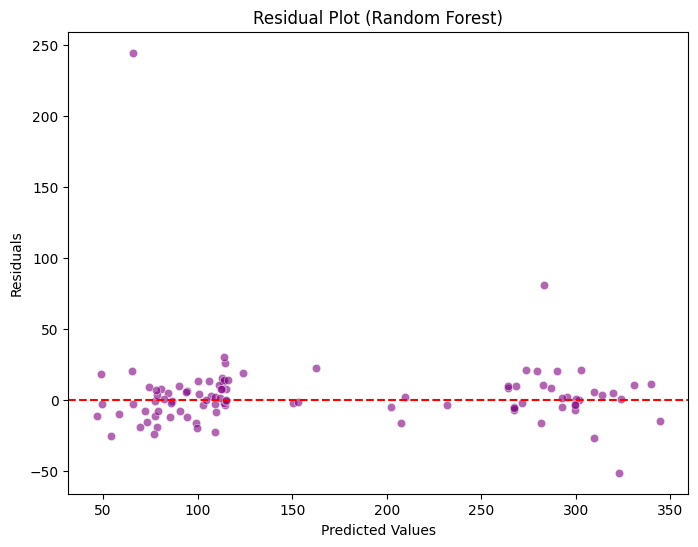

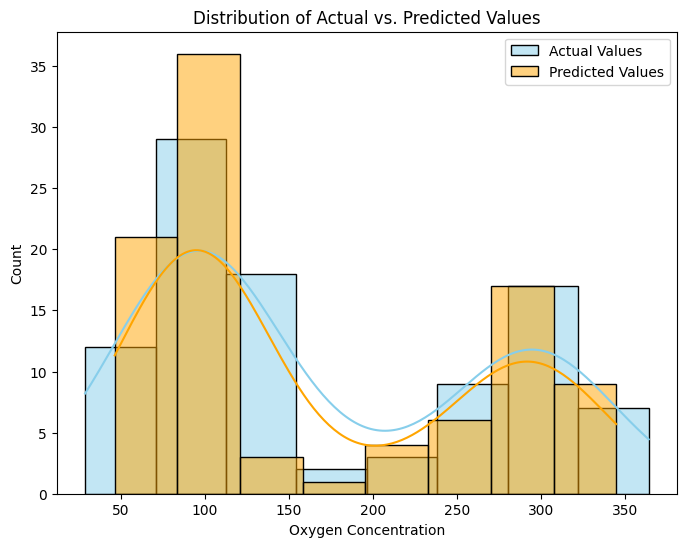

In [27]:
#scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs. Predicted Values (Random Forest)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

#residual plot
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_best, y=residuals, color='purple', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Random Forest)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

#distribution plot
plt.figure(figsize=(8, 6))
sns.histplot(y_test, label='Actual Values', color='skyblue', kde=True)
sns.histplot(y_pred_best, label='Predicted Values', color='orange', kde=True)
plt.title('Distribution of Actual vs. Predicted Values')
plt.xlabel('Oxygen Concentration')
plt.legend()
plt.show()


**What the plots show:**

- **Actual vs Predicted (first plot):** Points cluster tightly along the diagonal line, which represents a perfect prediction. The closer points are to the diagonal, the better. There is slight scatter at very low and very high oxygen values. The model is slightly less confident at the extremes of the range, which is common.

- **Residual plot (second plot):** Residuals are the difference between what the model predicted and what the actual value was. They are centered around zero with no obvious pattern, meaning the model is not systematically over-predicting or under predicting in any particular range.

- **Distribution plot (third plot):** The predicted values (orange) and actual values (blue) follow nearly identical distributions, confirming the model has learned the overall shape of the data well. The slight smoothing of extreme values is normal for Random Forest, averaging across hundreds of trees naturally dampens the most extreme predictions.